In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

In [7]:
# setup
df = pd.read_csv('../../data/processed/neighborhood_equity_model.csv')

# geopandas
neighborhoods_df = pd.read_csv('../../data/raw/denver_statistical_neighborhoods_20250409.csv')
neighborhoods_df = neighborhoods_df.drop(columns=['TYPOLOGY', 'NOTES'])
neighborhoods_df["the_geom"] = neighborhoods_df["the_geom"].apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(neighborhoods_df, geometry="the_geom", crs="EPSG:4326")

In [8]:
gdf_neighborhoods = gdf_neighborhoods.rename(columns={"NBHD_NAME": "neighborhood"})
gdf_merged = gdf_neighborhoods.merge(df, on='neighborhood', how='left')

## Top Equity Scores

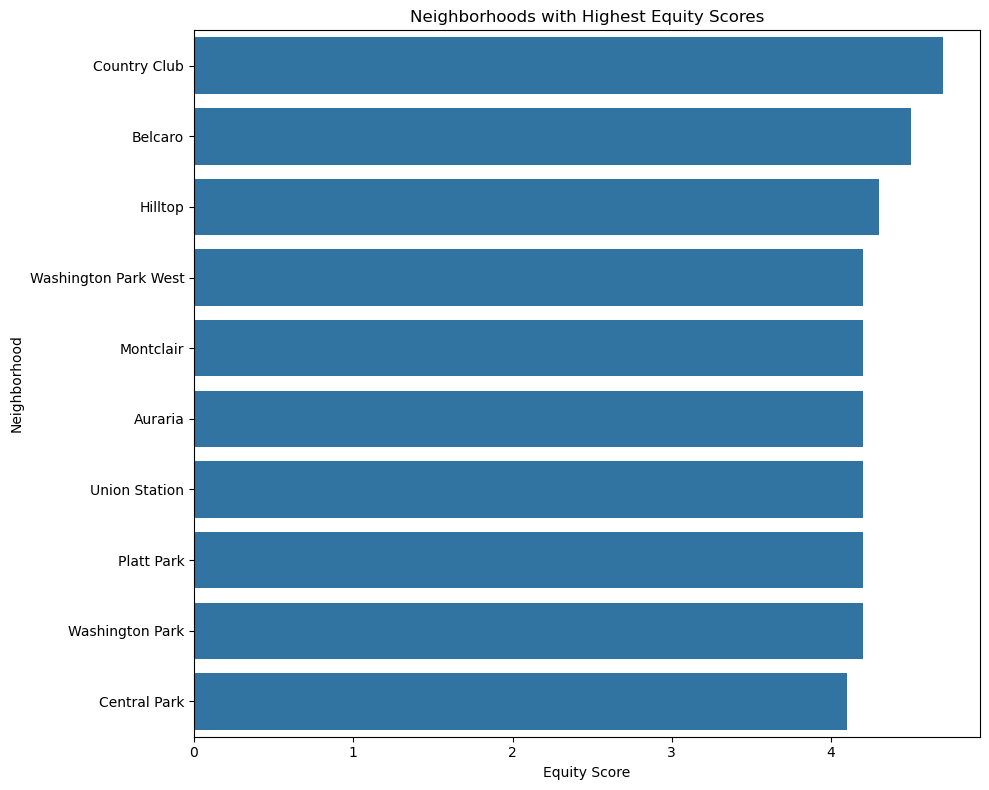

In [5]:
top_equity = df.sort_values("avgOverallEquityScore", ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    y=top_equity["neighborhood"], 
    x=top_equity["avgOverallEquityScore"], 
)
plt.title("Neighborhoods with Highest Equity Scores")
plt.xlabel("Equity Score")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

## Bottom Equity Scores

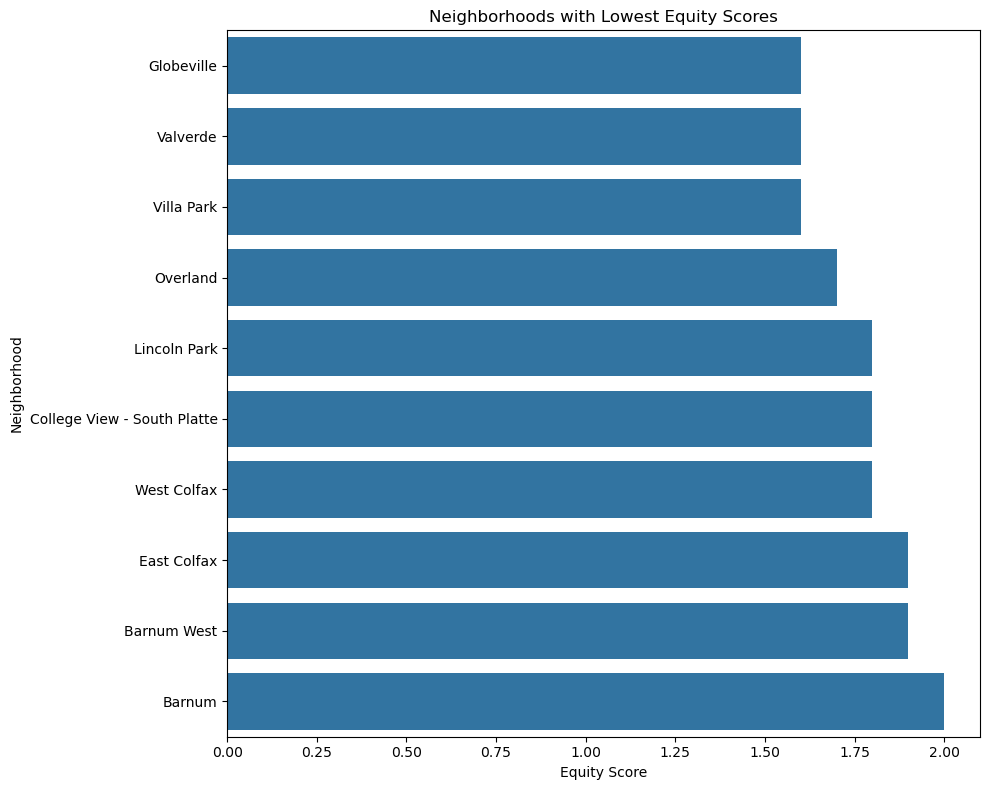

In [17]:
bottom_equity = df.sort_values("avgOverallEquityScore", ascending=True).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    y=bottom_equity["neighborhood"], 
    x=bottom_equity["avgOverallEquityScore"], 
)
plt.title("Neighborhoods with Lowest Equity Scores")
plt.xlabel("Equity Score")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

## Choropleth

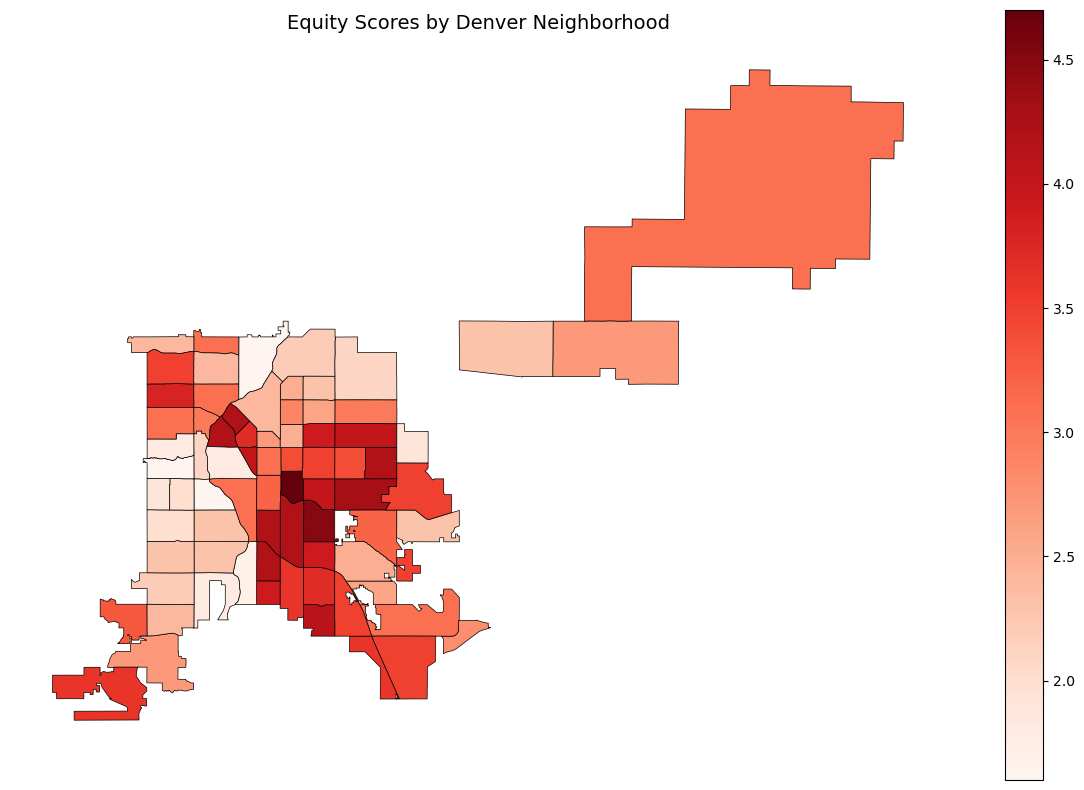

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
gdf_merged.plot(
    column='avgOverallEquityScore',
    cmap='Reds',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title('Equity Scores by Denver Neighborhood', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Compared with Other Features

In [10]:
list(df.columns)

['neighborhood',
 'avgOverallEquityScore',
 'Percent Hispanic',
 'Percent White',
 'Percent Black',
 'Percent Native American',
 'Percent Asian',
 'Percent Hawaiian/Pacific Islander',
 'Percent Other Race',
 'Percent Two or More Races',
 'Median Household Income',
 'Per Capita Income',
 'Median Home Value',
 'Percent Living in Poverty',
 'population_density',
 'percent_less_hs',
 'percent_at_hs',
 'percent_some_college',
 'percent_bachelors',
 'program_count_per1000',
 'crime_per1000']

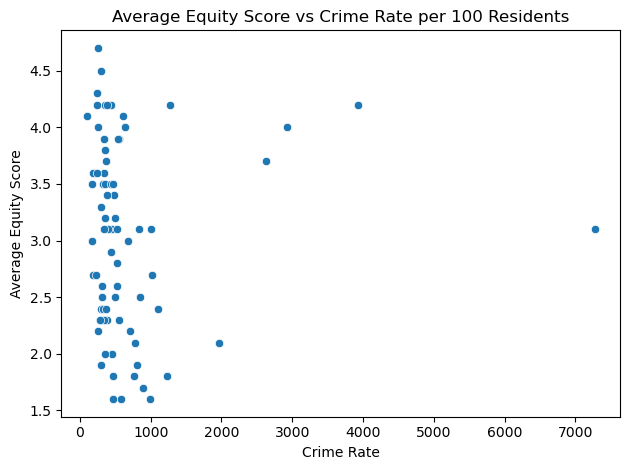

In [12]:
# Crime Rate
sns.scatterplot(data=df, x='crime_per1000', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Crime Rate per 100 Residents')
plt.xlabel('Crime Rate')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

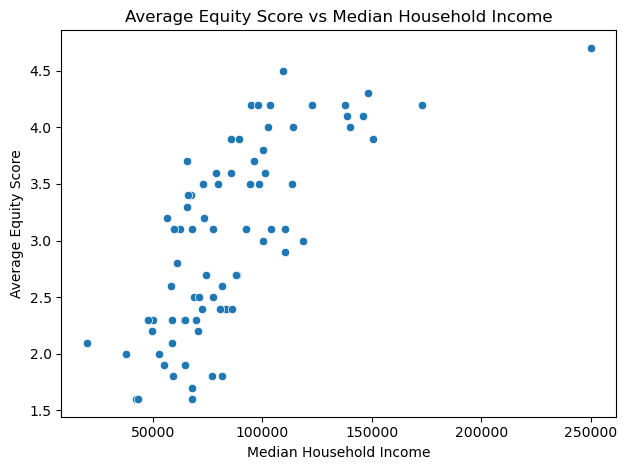

In [13]:
# Median Household Income
sns.scatterplot(data=df, x='Median Household Income', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Median Household Income')
plt.xlabel('Median Household Income')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

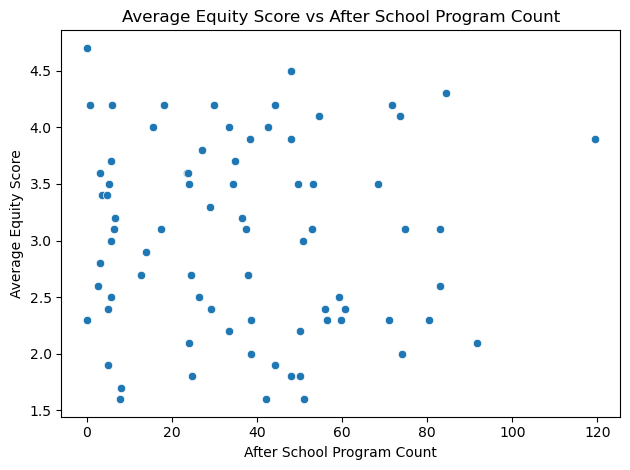

In [14]:
# After School Program Count
sns.scatterplot(data=df, x='program_count_per1000', y='avgOverallEquityScore')
plt.title('Average Equity Score vs After School Program Count')
plt.xlabel('After School Program Count')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

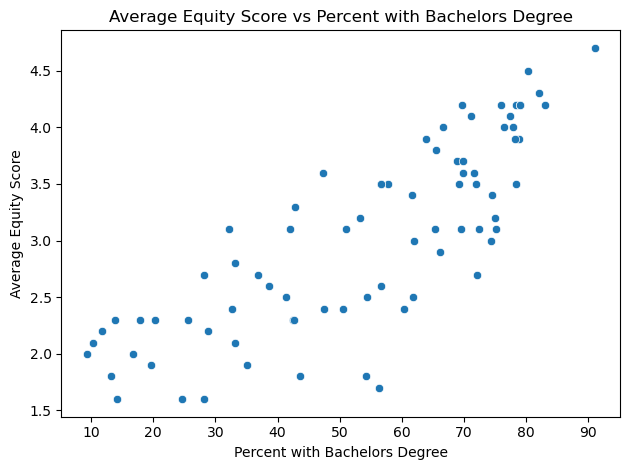

In [15]:
# education level
sns.scatterplot(data=df, x='percent_bachelors', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent with Bachelors Degree')
plt.xlabel('Percent with Bachelors Degree')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

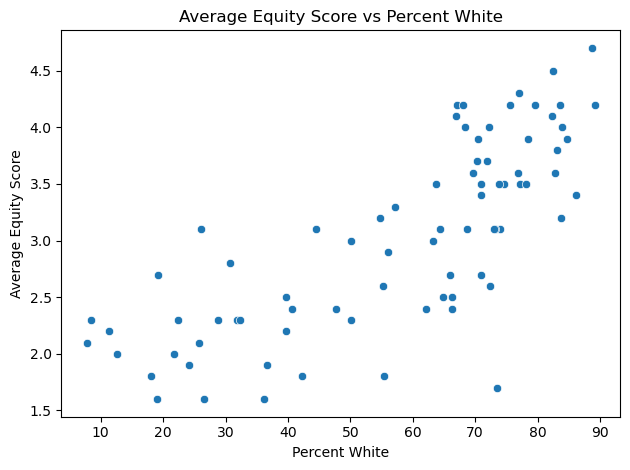

In [16]:
# Percent White
sns.scatterplot(data=df, x='Percent White', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent White')
plt.xlabel('Percent White')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

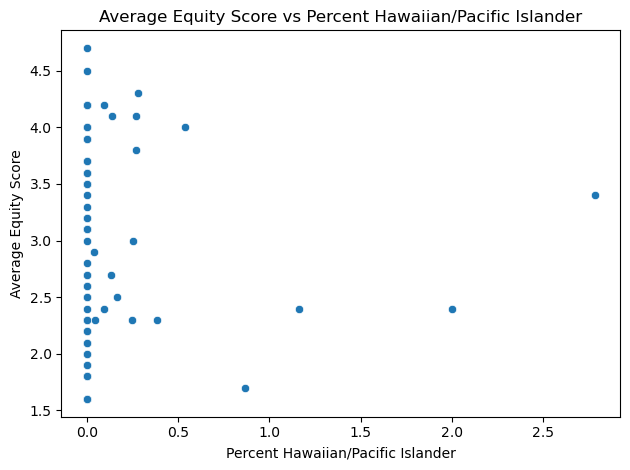

In [18]:
# Percent Hawaiian/Pacific Islander
sns.scatterplot(data=df, x='Percent Hawaiian/Pacific Islander', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent Hawaiian/Pacific Islander')
plt.xlabel('Percent Hawaiian/Pacific Islander')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

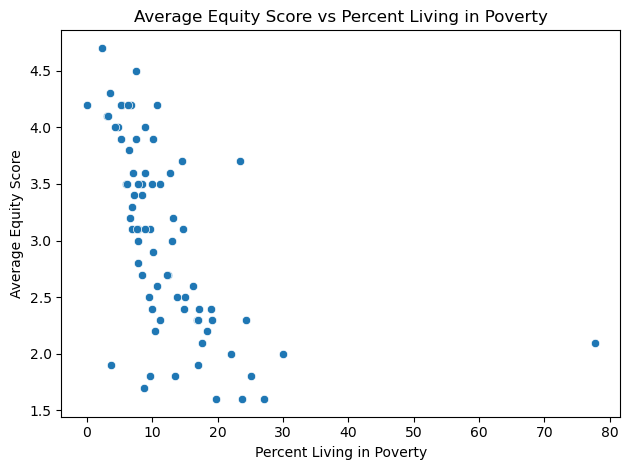

In [19]:
# Percent Living in Poverty
sns.scatterplot(data=df, x='Percent Living in Poverty', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent Living in Poverty')
plt.xlabel('Percent Living in Poverty')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

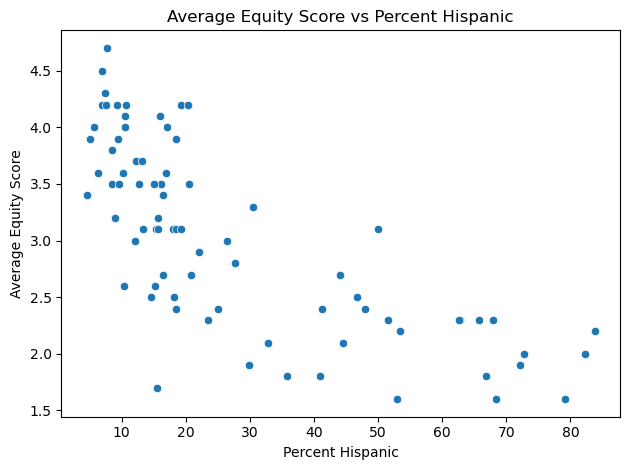

In [20]:
# Percent Hispanic
sns.scatterplot(data=df, x='Percent Hispanic', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent Hispanic')
plt.xlabel('Percent Hispanic')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

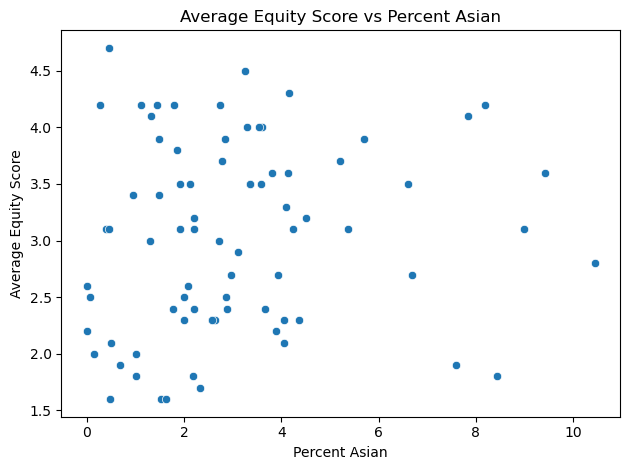

In [21]:
# Percent Asian
sns.scatterplot(data=df, x='Percent Asian', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent Asian')
plt.xlabel('Percent Asian')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()

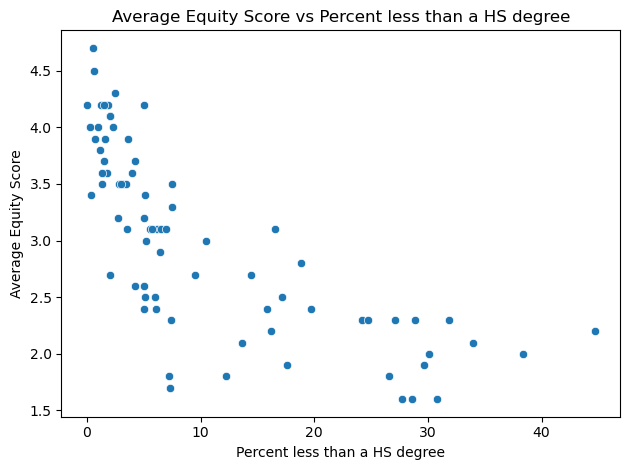

In [22]:
# percent_less_hs
sns.scatterplot(data=df, x='percent_less_hs', y='avgOverallEquityScore')
plt.title('Average Equity Score vs Percent less than a HS degree')
plt.xlabel('Percent less than a HS degree')
plt.ylabel('Average Equity Score')
plt.tight_layout()
plt.show()